# Task #36 (Story #6): Trực quan hóa tỉ lệ trễ theo vùng và hình thức thanh toán

Đọc `data/processed/orders_labeled.csv`, tính tỉ lệ trễ theo Phương án A (loại nhóm NA — thống nhất với Task #34/#35) theo:
- Bang người mua (`customer_state`) và bang người bán chính (`primary_seller_state`)
- Cặp vùng gửi–nhận cụ thể (`primary_seller_state` → `customer_state`) — đặc trưng rủi ro đã nêu ở docs/business-processes.md mục 4
- Hình thức thanh toán (`payment_has_*`)

Luôn ghi kèm cỡ mẫu (`n_orders`) mỗi nhóm để tránh kết luận sai do mẫu quá nhỏ.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/orders_labeled.csv", low_memory=False)

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

bool_cols = [
    "payment_has_boleto",
    "payment_has_credit_card",
    "payment_has_debit_card",
    "payment_has_not_defined",
    "payment_has_voucher",
]
for col in bool_cols:
    df[col] = df[col].astype("boolean")

df["is_delayed"] = df["is_delayed"].astype("boolean")

# Phương án A: loại nhóm NA
df_determined = df[df["is_delayed"].notna()].copy()
df_determined["is_delayed"] = df_determined["is_delayed"].astype(bool)

len(df_determined)

96476

## Tỉ lệ trễ theo bang người mua (`customer_state`)

In [2]:
by_customer_state = df_determined.groupby("customer_state")["is_delayed"].agg(n_orders="count", n_delayed="sum")
by_customer_state["pct_delayed"] = (by_customer_state["n_delayed"] / by_customer_state["n_orders"] * 100).round(2)
by_customer_state = by_customer_state.sort_values("pct_delayed", ascending=False)
by_customer_state

,n_orders,n_delayed,pct_delayed
customer_state,,,
AL,397,95,23.93
MA,717,141,19.67
PI,476,76,15.97
CE,1279,196,15.32
SE,335,51,15.22
BA,3256,457,14.04
RJ,12353,1664,13.47
TO,274,35,12.77
PA,946,117,12.37


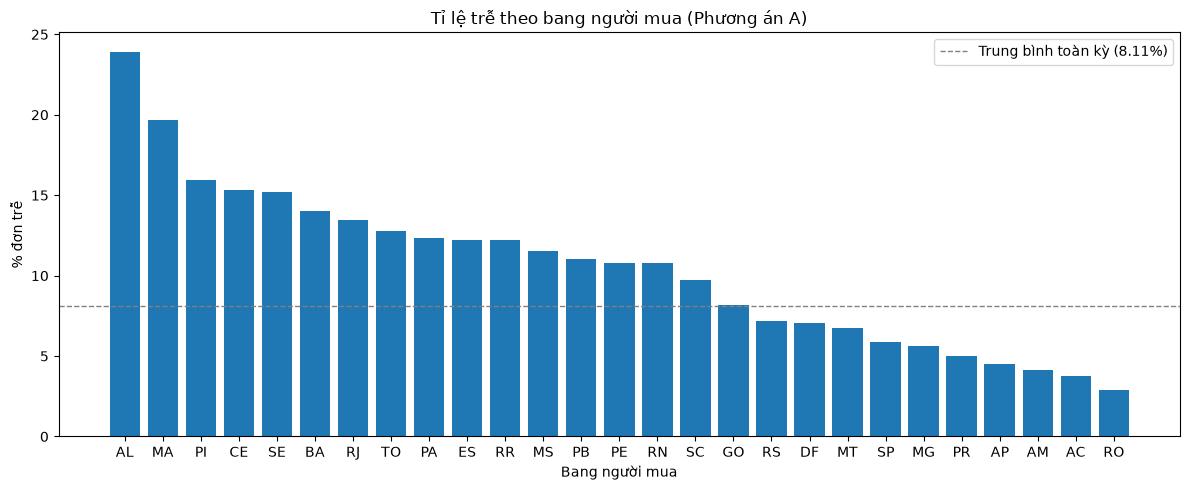

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(by_customer_state.index, by_customer_state["pct_delayed"])
ax.set_ylabel("% đơn trễ")
ax.set_xlabel("Bang người mua")
ax.set_title("Tỉ lệ trễ theo bang người mua (Phương án A)")
ax.axhline(8.11, color="gray", linestyle="--", linewidth=1, label="Trung bình toàn kỳ (8.11%)")
ax.legend()
plt.tight_layout()
plt.show()

## Tỉ lệ trễ theo bang người bán chính (`primary_seller_state`)

In [4]:
by_seller_state = df_determined.groupby("primary_seller_state")["is_delayed"].agg(n_orders="count", n_delayed="sum")
by_seller_state["pct_delayed"] = (by_seller_state["n_delayed"] / by_seller_state["n_orders"] * 100).round(2)
by_seller_state = by_seller_state.sort_values("pct_delayed", ascending=False)
by_seller_state

,n_orders,n_delayed,pct_delayed
primary_seller_state,,,
AM,3,2,66.67
MA,388,90,23.20
PA,8,1,12.50
RN,49,5,10.20
CE,84,8,9.52
SP,68393,6000,8.77
MS,47,4,8.51
RJ,4183,355,8.49
ES,310,22,7.10


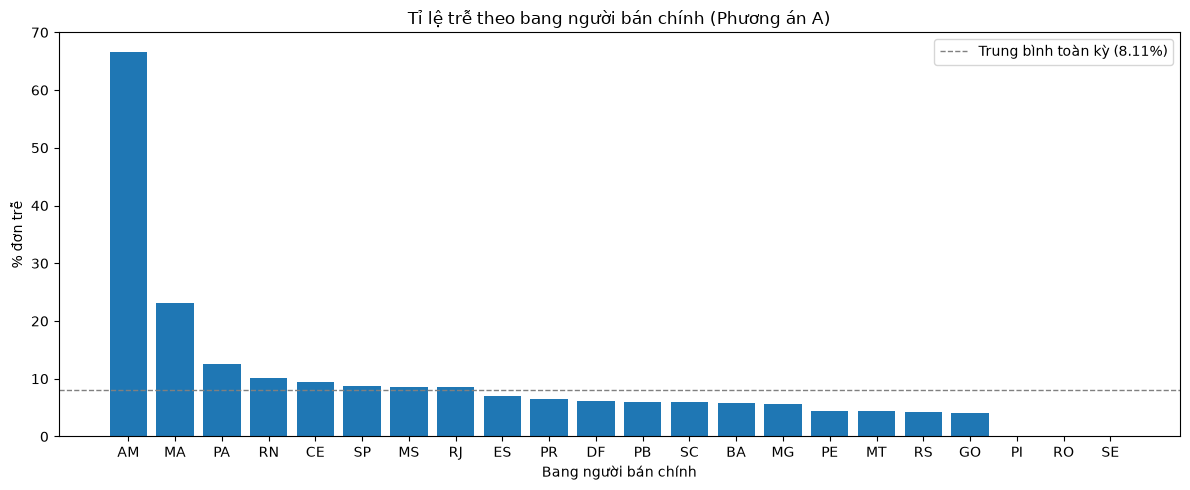

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(by_seller_state.index, by_seller_state["pct_delayed"])
ax.set_ylabel("% đơn trễ")
ax.set_xlabel("Bang người bán chính")
ax.set_title("Tỉ lệ trễ theo bang người bán chính (Phương án A)")
ax.axhline(8.11, color="gray", linestyle="--", linewidth=1, label="Trung bình toàn kỳ (8.11%)")
ax.legend()
plt.tight_layout()
plt.show()

## Tỉ lệ trễ theo cặp vùng gửi–nhận cụ thể (`primary_seller_state` → `customer_state`)

Có 415 cặp vùng khác nhau trên 96.476 đơn — rất nhiều cặp có cỡ mẫu quá nhỏ để kết luận. Chỉ xét các cặp có **từ 200 đơn trở lên** (đủ lớn để tỉ lệ % ổn định), sắp xếp theo tỉ lệ trễ giảm dần.

In [6]:
MIN_ROUTE_SAMPLE = 200

by_route = df_determined.groupby(["primary_seller_state", "customer_state"])["is_delayed"].agg(n_orders="count", n_delayed="sum")
by_route["pct_delayed"] = (by_route["n_delayed"] / by_route["n_orders"] * 100).round(2)

print(f"Tổng số cặp vùng: {len(by_route)}")
by_route_filtered = by_route[by_route["n_orders"] >= MIN_ROUTE_SAMPLE].sort_values("pct_delayed", ascending=False)
print(f"Số cặp vùng có >= {MIN_ROUTE_SAMPLE} đơn: {len(by_route_filtered)} (bỏ qua {len(by_route) - len(by_route_filtered)} cặp mẫu quá nhỏ)")
by_route_filtered

Tổng số cặp vùng: 410
Số cặp vùng có >= 200 đơn: 48 (bỏ qua 362 cặp mẫu quá nhỏ)


n_orders  n_delayed  pct_delayed
primary_seller_state customer_state                                  
SP                   AL                   255         67        26.27
                     MA                   492        104        21.14
                     PI                   329         60        18.24
                     SE                   208         34        16.35
                     RJ                  8156       1264        15.50
                     CE                   969        148        15.27
                     BA                  2308        345        14.95
                     MS                   476         69        14.50
                     ES                  1459        207        14.19
PR                   RJ                   970        135        13.92
SP                   PA                   683         90        13.18
                     RN                   332         40        12.05
                     SC                  2325        256        11.01
                     PB                   337         37        10.98
                     PE                  1131        122        10.79
MG                   BA                   366         39        10.66
SC                   RJ                   468         48        10.26
MG                   RJ                  1138        106         9.31
SP                   GO                  1420        131         9.23
RJ                   SP                  1319        120         9.10
                     PR                   202         18         8.91
RS                   RJ                   242         21         8.68
MG                   SC                   254         22         8.66
SP                   DF                  1382        114         8.25
                     RS                  3594        273         7.60
RJ                   MG                   550         40         7.27
PR                   SC                   390         26         6.67
SP                   MT                   650         43         6.62
RJ                   RJ                   956         62         6.49
SP                   MG                  7438        473         6.36
SC                   SC                   256         16         6.25
SP                   SP                 30727       1912         6.22
SC                   RS                   291         18         6.19
SP                   PR                  3117        167         5.36
PR                   MG                   821         43         5.24
RS                   RS                   289         15         5.19
PR                   RS                   579         30         5.18
SC                   MG                   426         22         5.16
MG                   RS                   278         14         5.04
PR                   PR                   714         31         4.34
SC                   SP                  1316         57         4.33
MG                   SP                  2547        110         4.32
PR                   SP                  2925        104         3.56
SC                   PR                   284          9         3.17
MG                   MG                  1527         48         3.14
DF                   SP                   307          9         2.93
RS                   SP                   665         15         2.26
MG                   PR                   364          7         1.92

## Tỉ lệ trễ theo hình thức thanh toán (`payment_has_*`)

Lưu ý: một đơn có thể dùng nhiều hình thức thanh toán cùng lúc (`payment_num_types` > 1 ở một số đơn), nên các nhóm dưới đây **không loại trừ lẫn nhau** — tổng `n_orders` các nhóm có thể vượt quá tổng số đơn.

In [7]:
payment_cols = [
    "payment_has_boleto",
    "payment_has_credit_card",
    "payment_has_debit_card",
    "payment_has_not_defined",
    "payment_has_voucher",
]

rows = []
for col in payment_cols:
    subset = df_determined[df_determined[col] == True]
    n_orders = len(subset)
    n_delayed = (subset["is_delayed"] == True).sum()
    rows.append({
        "payment_type": col.replace("payment_has_", ""),
        "n_orders": n_orders,
        "n_delayed": n_delayed,
        "pct_delayed": round(n_delayed / n_orders * 100, 2) if n_orders else None,
    })

by_payment = pd.DataFrame(rows).set_index("payment_type").sort_values("pct_delayed", ascending=False)
by_payment

,n_orders,n_delayed,pct_delayed
payment_type,,,
boleto,19191,1704,8.88
debit_card,1484,118,7.95
credit_card,74303,5900,7.94
voucher,3679,258,7.01
not_defined,0,0,NaN


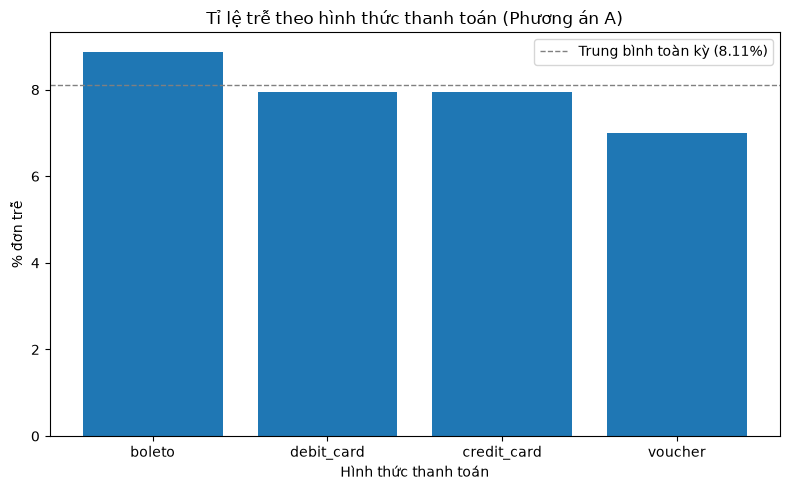

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(by_payment.index, by_payment["pct_delayed"])
ax.set_ylabel("% đơn trễ")
ax.set_xlabel("Hình thức thanh toán")
ax.set_title("Tỉ lệ trễ theo hình thức thanh toán (Phương án A)")
ax.axhline(8.11, color="gray", linestyle="--", linewidth=1, label="Trung bình toàn kỳ (8.11%)")
ax.legend()
plt.tight_layout()
plt.show()

## Kết luận

- **Theo bang người mua**: chênh lệch rất lớn và có cỡ mẫu đủ lớn để tin cậy — nhóm bang Đông Bắc/Bắc Brazil có tỉ lệ trễ cao nhất: **AL (23,93%, 397 đơn)**, **MA (19,67%, 717 đơn)**, **PI (15,97%, 476 đơn)**, **CE (15,32%, 1.279 đơn)**, trong khi các bang lớn ở Đông Nam/Nam có tỉ lệ thấp hơn nhiều: **SP (5,89%, 40.495 đơn)**, **MG (5,62%, 11.355 đơn)**, **PR (5,00%, 4.923 đơn)**. Vài bang cực trị (RR, AP, AM, AC, RO) có cỡ mẫu quá nhỏ (<250 đơn) nên tỉ lệ % kém tin cậy, cần thận trọng khi diễn giải.
- **Theo bang người bán chính**: hầu hết giá trị cực trị (AM 66,67%, PA 12,50%, RN 10,20%...) đều có cỡ mẫu rất nhỏ (<100 đơn), không đủ tin cậy. Trong nhóm mẫu lớn, **MA nổi bật với 23,20% (388 đơn)**; các bang bán hàng chính còn lại dao động 4-9%.
- **Theo cặp vùng gửi–nhận (>=200 đơn)**: tuyến **SP→AL (26,27%, 255 đơn)**, **SP→MA (21,14%, 492 đơn)**, **SP→RJ (15,50%, 8.156 đơn — mẫu lớn, tín hiệu chắc chắn)** có tỉ lệ trễ cao nhất; ngược lại **MG→PR (1,92%)**, **RS→SP (2,26%)**, **DF→SP (2,93%)** có tỉ lệ trễ thấp nhất. Đây là chỉ số tỉ lệ trễ so với ngày ước tính, khác với thời gian giao hàng tuyệt đối (số ngày) đã ghi trong docs/business-processes.md mục 4 — hai chỉ số này không nhất thiết đồng biến (tuyến xa có thể vẫn "đúng hạn" nếu ngày ước tính đã tính đủ khoảng cách).
- **Theo hình thức thanh toán**: chênh lệch nhỏ, không rõ tín hiệu mạnh — boleto cao nhất (8,88%), voucher thấp nhất (7,01%), đều gần trung bình toàn kỳ (8,11%). `not_defined` không có đơn nào dùng riêng lẻ (luôn đi kèm hình thức khác) nên không tính được tỉ lệ.